In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df_adhd = pd.read_csv(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Preprocessed_Datasets\Phenomic\ADHD200_Preprocessed_Phenomic_Dataset.csv")
df_adhd.head(10)

,ADHD Index,Med Status_1,Full4 IQ,Age,Med Status_-999,Verbal IQ,Performance IQ,Secondary Dx _None,Med Status_2,Gender_0.0,...,QC_Rest_1,Site_5.0,Site_3.0,DX,sMRI_path,subject,ScanDir ID,ADHD Measure,Inattentive,Hyper/Impulsive
0,47.0,1.0,122.0,10.73,0.0,121.0,119.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,2371032.0,2,55.0,43.0
1,90.0,1.0,106.0,12.99,0.0,122.0,108.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,2026113.0,2,89.0,78.0
2,42.0,1.0,89.0,8.12,0.0,85.0,98.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,3434578.0,2,42.0,43.0
3,42.0,1.0,97.0,10.81,0.0,85.0,86.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,8628223.0,2,49.0,49.0
4,87.0,1.0,89.0,12.65,0.0,89.0,88.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,1623716.0,2,90.0,90.0
5,54.0,1.0,108.0,12.87,0.0,124.0,104.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,1594156.0,2,55.0,57.0
6,40.0,1.0,106.0,9.97,0.0,91.0,127.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,2930625.0,2,40.0,50.0
7,64.0,1.0,88.0,11.65,0.0,93.0,98.0,1.0,0.0,0.0,...,1.0,0.0,1.0,1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,3154996.0,2,74.0,58.0
8,71.0,1.0,99.0,11.95,0.0,93.0,108.0,1.0,0.0,0.0,...,1.0,0.0,1.0,1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,3160561.0,2,62.0,70.0
9,87.0,1.0,94.0,10.50,0.0,93.0,100.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,4275075.0,2,75.0,69.0


In [3]:
df_dyslexia = pd.read_csv(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Preprocessed_Datasets\Phenomic\OpenNeuro_dyslexia_phenomic_Preprocessed_Dataset.csv")
df_dyslexia.head(10)

,participant_id,age,sex,maternal_education,home_literacy,family_history_dyslexia,phonological_processing,rapid_naming,working_memory,reading_accuracy,reading_fluency,spelling_accuracy,vocabulary_score,euler_number,DX
0,sub-000,10,1,12,1.962823,1,94.614662,27.448325,101.199647,83.786747,89.871476,85.622901,101.815704,-163.482153,1
1,sub-001,11,1,13,-0.385060,0,103.481928,31.058749,124.176859,80.924500,60.164410,95.798554,107.448725,-197.027398,1
2,sub-002,9,0,11,0.328495,0,95.913584,27.484597,105.396051,76.444328,96.124567,59.127176,74.283189,-137.285755,1
3,sub-003,11,1,11,-0.072283,0,98.876337,23.749658,102.530594,74.720632,85.341629,67.370239,102.352664,-180.215922,1
4,sub-004,11,0,10,0.901825,1,108.652573,27.205026,121.922893,100.000000,89.599632,89.027899,70.216055,-162.353867,1
5,sub-005,8,0,14,1.274677,1,64.124175,31.700297,86.917695,88.341187,76.896472,84.306677,97.366437,-158.929968,1
6,sub-006,9,1,13,0.257997,1,80.996583,33.357403,130.354008,74.088710,73.591287,100.000000,109.869044,-253.334135,1
7,sub-007,9,0,20,0.469117,0,100.663891,33.307114,95.768500,87.878659,103.183235,92.907890,115.686687,-197.500698,1
8,sub-008,9,0,19,-0.620604,0,93.936745,32.122365,81.728380,95.620162,106.626850,90.025094,105.016901,-216.617724,1
9,sub-009,11,1,11,0.436714,1,101.941169,29.159533,109.802529,86.675176,96.271479,70.834536,110.130861,-147.807700,1


In [4]:
df_asd = pd.read_csv(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Preprocessed_Datasets\Phenomic\ASD_cleaned.csv")
df_asd.head(10)

,DX_GROUP,AGE_AT_SCAN,SEX,FIQ,VIQ,PIQ,CURRENT_MED_STATUS,HANDEDNESS_CATEGORY_Ambi,HANDEDNESS_CATEGORY_L,HANDEDNESS_CATEGORY_L->R,HANDEDNESS_CATEGORY_Mixed,HANDEDNESS_CATEGORY_R,DX
0,1.0,16.770000,NaN,103.0,116.0,89.0,0,1.0,0.0,0.0,0.0,0.0,1
1,1.0,24.450000,NaN,124.0,128.0,115.0,1,0.0,0.0,0.0,0.0,1.0,1
2,1.0,19.090000,NaN,113.0,108.0,117.0,0,0.0,0.0,0.0,0.0,1.0,1
3,1.0,13.730000,NaN,119.0,117.0,118.0,1,0.0,0.0,0.0,0.0,1.0,1
4,1.0,13.370000,NaN,109.0,99.0,119.0,0,0.0,1.0,0.0,0.0,0.0,1
5,1.0,17.780000,NaN,110.0,106.0,112.0,0,0.0,0.0,0.0,0.0,1.0,1
6,1.0,32.450000,NaN,123.0,123.0,114.0,1,0.0,0.0,0.0,0.0,1.0,1
7,1.0,32.724638,NaN,126.0,118.0,128.0,1,0.0,0.0,0.0,0.0,1.0,1
8,1.0,32.724638,NaN,81.0,81.0,93.0,0,0.0,1.0,0.0,0.0,0.0,1
9,1.0,16.930000,NaN,111.0,101.0,120.0,0,0.0,1.0,0.0,0.0,0.0,1


- #### Map heterogeneous phenotypes into a shared latent clinical space

In [5]:
print("ADHD200 Dataset Shape: ", df_adhd.shape)
print("Dyslexia Dataset Shape: ", df_dyslexia.shape)
# print("ADHD + Dyslexia Shape: ", df_adhd_dyslexia.shape)
print("ABIDE Dataset Shape: ", df_asd.shape)

ADHD200 Dataset Shape:  (469, 23)
Dyslexia Dataset Shape:  (500, 15)
ABIDE Dataset Shape:  (1112, 13)


### Feature harmonization

#### Harmonize core Features

In [6]:
def harmonize_core_features(df, dataset_name):

    core = pd.DataFrame(index=df.index)

    # ---------- Age ----------
    core["Age"] = df.get("AGE_AT_SCAN", df.get("Age", np.nan))

    # ---------- Sex ----------
    if "SEX" in df.columns:
        core["Sex"] = df["SEX"]
    elif "Gender_0.0" in df.columns:
        core["Sex"] = df["Gender_0.0"]
    else:
        core["Sex"] = df.get("Sex", np.nan)

    # ---------- IQ ----------
    core["FIQ"] = df.get("FIQ", np.nan)
    core["VIQ"] = df.get("VIQ", df.get("Verbal IQ", np.nan))
    core["PIQ"] = df.get("PIQ", df.get("Performance IQ", np.nan))

    # ---------- Handedness ----------
    if "HANDEDNESS_CATEGORY_R" in df.columns:
        handed_cols = [
            "HANDEDNESS_CATEGORY_R",
            "HANDEDNESS_CATEGORY_L",
            "HANDEDNESS_CATEGORY_Ambi",
            "HANDEDNESS_CATEGORY_Mixed"
        ]
        existing = [c for c in handed_cols if c in df.columns]
        core["Handedness"] = df[existing].idxmax(axis=1)
    else:
        core["Handedness"] = df.get("Handedness", "Unknown")

    # ---------- Medication ----------
    core["MedicationStatus"] = df.get("CURRENT_MED_STATUS", df.get("Med Status_1", np.nan))

    # ---------- Dataset source ----------
    core["Dataset"] = dataset_name

    return core


In [7]:
core_adhd = harmonize_core_features(df_adhd, "ADHD")
core_dyslexia = harmonize_core_features(df_dyslexia, "Dyslexia")
core_asd = harmonize_core_features(df_asd, "ASD")

In [8]:
core_adhd.head(10)

,Age,Sex,FIQ,VIQ,PIQ,Handedness,MedicationStatus,Dataset
0,10.73,1.0,NaN,121.0,119.0,Unknown,1.0,ADHD
1,12.99,1.0,NaN,122.0,108.0,Unknown,1.0,ADHD
2,8.12,1.0,NaN,85.0,98.0,Unknown,1.0,ADHD
3,10.81,1.0,NaN,85.0,86.0,Unknown,1.0,ADHD
4,12.65,1.0,NaN,89.0,88.0,Unknown,1.0,ADHD
5,12.87,0.0,NaN,124.0,104.0,Unknown,1.0,ADHD
6,9.97,0.0,NaN,91.0,127.0,Unknown,1.0,ADHD
7,11.65,0.0,NaN,93.0,98.0,Unknown,1.0,ADHD
8,11.95,0.0,NaN,93.0,108.0,Unknown,1.0,ADHD
9,10.50,1.0,NaN,93.0,100.0,Unknown,1.0,ADHD


In [9]:
core_dyslexia.head(10)

,Age,Sex,FIQ,VIQ,PIQ,Handedness,MedicationStatus,Dataset
0,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia
1,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia
2,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia
3,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia
4,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia
5,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia
6,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia
7,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia
8,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia
9,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia


In [10]:
core_asd.head(10)

,Age,Sex,FIQ,VIQ,PIQ,Handedness,MedicationStatus,Dataset
0,16.770000,NaN,103.0,116.0,89.0,HANDEDNESS_CATEGORY_Ambi,0,ASD
1,24.450000,NaN,124.0,128.0,115.0,HANDEDNESS_CATEGORY_R,1,ASD
2,19.090000,NaN,113.0,108.0,117.0,HANDEDNESS_CATEGORY_R,0,ASD
3,13.730000,NaN,119.0,117.0,118.0,HANDEDNESS_CATEGORY_R,1,ASD
4,13.370000,NaN,109.0,99.0,119.0,HANDEDNESS_CATEGORY_L,0,ASD
5,17.780000,NaN,110.0,106.0,112.0,HANDEDNESS_CATEGORY_R,0,ASD
6,32.450000,NaN,123.0,123.0,114.0,HANDEDNESS_CATEGORY_R,1,ASD
7,32.724638,NaN,126.0,118.0,128.0,HANDEDNESS_CATEGORY_R,1,ASD
8,32.724638,NaN,81.0,81.0,93.0,HANDEDNESS_CATEGORY_L,0,ASD
9,16.930000,NaN,111.0,101.0,120.0,HANDEDNESS_CATEGORY_L,0,ASD


#### Derived Features (Important for representation learning)

In [11]:
def add_derived_features(df):
    df = df.copy()

    df["IQ_mean"] = df[["FIQ","VIQ","PIQ"]].mean(axis=1)
    df["VIQ_PIQ_ratio"] = df["VIQ"] / (df["PIQ"] + 1e-5)
    df["FIQ_deviation"] = df["FIQ"] - df["IQ_mean"]
    df["Age_IQ_interaction"] = df["Age"] * df["IQ_mean"]

    return df

In [12]:
core_adhd = add_derived_features(core_adhd)
core_dyslexia = add_derived_features(core_dyslexia)
core_asd = add_derived_features(core_asd)

In [13]:
core_adhd.head(10)

,Age,Sex,FIQ,VIQ,PIQ,Handedness,MedicationStatus,Dataset,IQ_mean,VIQ_PIQ_ratio,FIQ_deviation,Age_IQ_interaction
0,10.73,1.0,NaN,121.0,119.0,Unknown,1.0,ADHD,120.0,1.016807,NaN,1287.600
1,12.99,1.0,NaN,122.0,108.0,Unknown,1.0,ADHD,115.0,1.129630,NaN,1493.850
2,8.12,1.0,NaN,85.0,98.0,Unknown,1.0,ADHD,91.5,0.867347,NaN,742.980
3,10.81,1.0,NaN,85.0,86.0,Unknown,1.0,ADHD,85.5,0.988372,NaN,924.255
4,12.65,1.0,NaN,89.0,88.0,Unknown,1.0,ADHD,88.5,1.011364,NaN,1119.525
5,12.87,0.0,NaN,124.0,104.0,Unknown,1.0,ADHD,114.0,1.192308,NaN,1467.180
6,9.97,0.0,NaN,91.0,127.0,Unknown,1.0,ADHD,109.0,0.716535,NaN,1086.730
7,11.65,0.0,NaN,93.0,98.0,Unknown,1.0,ADHD,95.5,0.948979,NaN,1112.575
8,11.95,0.0,NaN,93.0,108.0,Unknown,1.0,ADHD,100.5,0.861111,NaN,1200.975
9,10.50,1.0,NaN,93.0,100.0,Unknown,1.0,ADHD,96.5,0.930000,NaN,1013.250


In [14]:
core_dyslexia.head(10)

,Age,Sex,FIQ,VIQ,PIQ,Handedness,MedicationStatus,Dataset,IQ_mean,VIQ_PIQ_ratio,FIQ_deviation,Age_IQ_interaction
0,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Dyslexia,NaN,NaN,NaN,NaN


In [15]:
core_asd.head(10)

,Age,Sex,FIQ,VIQ,PIQ,Handedness,MedicationStatus,Dataset,IQ_mean,VIQ_PIQ_ratio,FIQ_deviation,Age_IQ_interaction
0,16.770000,NaN,103.0,116.0,89.0,HANDEDNESS_CATEGORY_Ambi,0,ASD,102.666667,1.303371,0.333333,1721.720000
1,24.450000,NaN,124.0,128.0,115.0,HANDEDNESS_CATEGORY_R,1,ASD,122.333333,1.113043,1.666667,2991.050000
2,19.090000,NaN,113.0,108.0,117.0,HANDEDNESS_CATEGORY_R,0,ASD,112.666667,0.923077,0.333333,2150.806667
3,13.730000,NaN,119.0,117.0,118.0,HANDEDNESS_CATEGORY_R,1,ASD,118.000000,0.991525,1.000000,1620.140000
4,13.370000,NaN,109.0,99.0,119.0,HANDEDNESS_CATEGORY_L,0,ASD,109.000000,0.831933,0.000000,1457.330000
5,17.780000,NaN,110.0,106.0,112.0,HANDEDNESS_CATEGORY_R,0,ASD,109.333333,0.946428,0.666667,1943.946667
6,32.450000,NaN,123.0,123.0,114.0,HANDEDNESS_CATEGORY_R,1,ASD,120.000000,1.078947,3.000000,3894.000000
7,32.724638,NaN,126.0,118.0,128.0,HANDEDNESS_CATEGORY_R,1,ASD,124.000000,0.921875,2.000000,4057.855050
8,32.724638,NaN,81.0,81.0,93.0,HANDEDNESS_CATEGORY_L,0,ASD,85.000000,0.870968,-4.000000,2781.594187
9,16.930000,NaN,111.0,101.0,120.0,HANDEDNESS_CATEGORY_L,0,ASD,110.666667,0.841667,0.333333,1873.586667


### Multi Label Targets

In [16]:
# Multi Label Targets

def create_labels(df, dataset):

    labels = pd.DataFrame(index=df.index)

    if dataset == "ADHD":
        labels["ADHD"] = (df["DX"] == 1).astype(int)
        labels["ASD"] = 0
        labels["Dyslexia"] = 0

    elif dataset == "ASD":
        labels["ADHD"] = 0
        labels["ASD"] = (df["DX"] == 1).astype(int)
        labels["Dyslexia"] = 0

    elif dataset == "Dyslexia":
        labels["ADHD"] = 0
        labels["ASD"] = 0
        labels["Dyslexia"] = (df["DX"] == 1).astype(int)

    return labels

In [17]:
labels_adhd = create_labels(df_adhd, "ADHD")
labels_dyslexia = create_labels(df_dyslexia, "Dyslexia")
labels_asd = create_labels(df_asd, "ASD")

In [18]:
# Merge Datasets

phenomic = pd.concat([
    pd.concat([core_adhd, labels_adhd], axis=1),
    pd.concat([core_dyslexia, labels_dyslexia], axis=1),
    pd.concat([core_asd, labels_asd], axis=1)
], ignore_index=True)


In [19]:
phenomic.head(10)

,Age,Sex,FIQ,VIQ,PIQ,Handedness,MedicationStatus,Dataset,IQ_mean,VIQ_PIQ_ratio,FIQ_deviation,Age_IQ_interaction,ADHD,ASD,Dyslexia
0,10.73,1.0,NaN,121.0,119.0,Unknown,1.0,ADHD,120.0,1.016807,NaN,1287.600,0,0,0
1,12.99,1.0,NaN,122.0,108.0,Unknown,1.0,ADHD,115.0,1.129630,NaN,1493.850,1,0,0
2,8.12,1.0,NaN,85.0,98.0,Unknown,1.0,ADHD,91.5,0.867347,NaN,742.980,0,0,0
3,10.81,1.0,NaN,85.0,86.0,Unknown,1.0,ADHD,85.5,0.988372,NaN,924.255,0,0,0
4,12.65,1.0,NaN,89.0,88.0,Unknown,1.0,ADHD,88.5,1.011364,NaN,1119.525,1,0,0
5,12.87,0.0,NaN,124.0,104.0,Unknown,1.0,ADHD,114.0,1.192308,NaN,1467.180,0,0,0
6,9.97,0.0,NaN,91.0,127.0,Unknown,1.0,ADHD,109.0,0.716535,NaN,1086.730,0,0,0
7,11.65,0.0,NaN,93.0,98.0,Unknown,1.0,ADHD,95.5,0.948979,NaN,1112.575,1,0,0
8,11.95,0.0,NaN,93.0,108.0,Unknown,1.0,ADHD,100.5,0.861111,NaN,1200.975,1,0,0
9,10.50,1.0,NaN,93.0,100.0,Unknown,1.0,ADHD,96.5,0.930000,NaN,1013.250,1,0,0


In [20]:
# Add Control data Column

phenomic["Control"] = ((phenomic["ADHD"] == 0) &
                       (phenomic["ASD"] == 0) &
                       (phenomic["Dyslexia"] == 0)).astype(int)

print("Control Column Value count: \n", phenomic["Control"].value_counts())
phenomic[phenomic["Control"] == 1].head()

Control Column Value count: 
 Control
0    1245
1     836
Name: count, dtype: int64


,Age,Sex,FIQ,VIQ,PIQ,Handedness,MedicationStatus,Dataset,IQ_mean,VIQ_PIQ_ratio,FIQ_deviation,Age_IQ_interaction,ADHD,ASD,Dyslexia,Control
0,10.73,1.0,NaN,121.0,119.0,Unknown,1.0,ADHD,120.0,1.016807,NaN,1287.600,0,0,0,1
2,8.12,1.0,NaN,85.0,98.0,Unknown,1.0,ADHD,91.5,0.867347,NaN,742.980,0,0,0,1
3,10.81,1.0,NaN,85.0,86.0,Unknown,1.0,ADHD,85.5,0.988372,NaN,924.255,0,0,0,1
5,12.87,0.0,NaN,124.0,104.0,Unknown,1.0,ADHD,114.0,1.192308,NaN,1467.180,0,0,0,1
6,9.97,0.0,NaN,91.0,127.0,Unknown,1.0,ADHD,109.0,0.716535,NaN,1086.730,0,0,0,1


### Categorical Encoding

In [21]:
categorical_cols = ["Handedness", "Dataset"]
phenomic = pd.get_dummies(phenomic, columns=categorical_cols)

In [22]:
print(phenomic[['ADHD','ASD','Dyslexia']].sum())

ADHD        206
ASD         539
Dyslexia    500
dtype: int64


In [23]:
phenomic[['ADHD','ASD','Dyslexia']].value_counts()

ADHD  ASD  Dyslexia
0     0    0           836
      1    0           539
      0    1           500
1     0    0           206
Name: count, dtype: int64

In [24]:
phenomic.head(10)

,Age,Sex,FIQ,VIQ,PIQ,MedicationStatus,IQ_mean,VIQ_PIQ_ratio,FIQ_deviation,Age_IQ_interaction,...,Dyslexia,Control,Handedness_HANDEDNESS_CATEGORY_Ambi,Handedness_HANDEDNESS_CATEGORY_L,Handedness_HANDEDNESS_CATEGORY_Mixed,Handedness_HANDEDNESS_CATEGORY_R,Handedness_Unknown,Dataset_ADHD,Dataset_ASD,Dataset_Dyslexia
0,10.73,1.0,NaN,121.0,119.0,1.0,120.0,1.016807,NaN,1287.600,...,0,1,False,False,False,False,True,True,False,False
1,12.99,1.0,NaN,122.0,108.0,1.0,115.0,1.129630,NaN,1493.850,...,0,0,False,False,False,False,True,True,False,False
2,8.12,1.0,NaN,85.0,98.0,1.0,91.5,0.867347,NaN,742.980,...,0,1,False,False,False,False,True,True,False,False
3,10.81,1.0,NaN,85.0,86.0,1.0,85.5,0.988372,NaN,924.255,...,0,1,False,False,False,False,True,True,False,False
4,12.65,1.0,NaN,89.0,88.0,1.0,88.5,1.011364,NaN,1119.525,...,0,0,False,False,False,False,True,True,False,False
5,12.87,0.0,NaN,124.0,104.0,1.0,114.0,1.192308,NaN,1467.180,...,0,1,False,False,False,False,True,True,False,False
6,9.97,0.0,NaN,91.0,127.0,1.0,109.0,0.716535,NaN,1086.730,...,0,1,False,False,False,False,True,True,False,False
7,11.65,0.0,NaN,93.0,98.0,1.0,95.5,0.948979,NaN,1112.575,...,0,0,False,False,False,False,True,True,False,False
8,11.95,0.0,NaN,93.0,108.0,1.0,100.5,0.861111,NaN,1200.975,...,0,0,False,False,False,False,True,True,False,False
9,10.50,1.0,NaN,93.0,100.0,1.0,96.5,0.930000,NaN,1013.250,...,0,0,False,False,False,False,True,True,False,False


### Missingness Indicators

In [25]:
missing_indicators = phenomic.isnull().astype(int)
missing_indicators.columns = [c + "_missing" for c in phenomic.columns]
missing_indicators

,Age_missing,Sex_missing,FIQ_missing,VIQ_missing,PIQ_missing,MedicationStatus_missing,IQ_mean_missing,VIQ_PIQ_ratio_missing,FIQ_deviation_missing,Age_IQ_interaction_missing,...,Dyslexia_missing,Control_missing,Handedness_HANDEDNESS_CATEGORY_Ambi_missing,Handedness_HANDEDNESS_CATEGORY_L_missing,Handedness_HANDEDNESS_CATEGORY_Mixed_missing,Handedness_HANDEDNESS_CATEGORY_R_missing,Handedness_Unknown_missing,Dataset_ADHD_missing,Dataset_ASD_missing,Dataset_Dyslexia_missing
0,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2076,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2077,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2078,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2079,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Imputation

In [26]:
numeric_cols = phenomic.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="median")
phenomic[numeric_cols] = imputer.fit_transform(phenomic[numeric_cols])

phenomic.head(10)

,Age,Sex,FIQ,VIQ,PIQ,MedicationStatus,IQ_mean,VIQ_PIQ_ratio,FIQ_deviation,Age_IQ_interaction,...,Dyslexia,Control,Handedness_HANDEDNESS_CATEGORY_Ambi,Handedness_HANDEDNESS_CATEGORY_L,Handedness_HANDEDNESS_CATEGORY_Mixed,Handedness_HANDEDNESS_CATEGORY_R,Handedness_Unknown,Dataset_ADHD,Dataset_ASD,Dataset_Dyslexia
0,10.73,1.0,108.0,121.0,119.0,1.0,120.0,1.016807,0.333333,1287.600,...,0.0,1.0,False,False,False,False,True,True,False,False
1,12.99,1.0,108.0,122.0,108.0,1.0,115.0,1.129630,0.333333,1493.850,...,0.0,0.0,False,False,False,False,True,True,False,False
2,8.12,1.0,108.0,85.0,98.0,1.0,91.5,0.867347,0.333333,742.980,...,0.0,1.0,False,False,False,False,True,True,False,False
3,10.81,1.0,108.0,85.0,86.0,1.0,85.5,0.988372,0.333333,924.255,...,0.0,1.0,False,False,False,False,True,True,False,False
4,12.65,1.0,108.0,89.0,88.0,1.0,88.5,1.011364,0.333333,1119.525,...,0.0,0.0,False,False,False,False,True,True,False,False
5,12.87,0.0,108.0,124.0,104.0,1.0,114.0,1.192308,0.333333,1467.180,...,0.0,1.0,False,False,False,False,True,True,False,False
6,9.97,0.0,108.0,91.0,127.0,1.0,109.0,0.716535,0.333333,1086.730,...,0.0,1.0,False,False,False,False,True,True,False,False
7,11.65,0.0,108.0,93.0,98.0,1.0,95.5,0.948979,0.333333,1112.575,...,0.0,0.0,False,False,False,False,True,True,False,False
8,11.95,0.0,108.0,93.0,108.0,1.0,100.5,0.861111,0.333333,1200.975,...,0.0,0.0,False,False,False,False,True,True,False,False
9,10.50,1.0,108.0,93.0,100.0,1.0,96.5,0.930000,0.333333,1013.250,...,0.0,0.0,False,False,False,False,True,True,False,False


In [27]:
for column in phenomic:
    print(column)

Age
Sex
FIQ
VIQ
PIQ
MedicationStatus
IQ_mean
VIQ_PIQ_ratio
FIQ_deviation
Age_IQ_interaction
ADHD
ASD
Dyslexia
Control
Handedness_HANDEDNESS_CATEGORY_Ambi
Handedness_HANDEDNESS_CATEGORY_L
Handedness_HANDEDNESS_CATEGORY_Mixed
Handedness_HANDEDNESS_CATEGORY_R
Handedness_Unknown
Dataset_ADHD
Dataset_ASD
Dataset_Dyslexia


### Scaling (Important for Neural Networks)

In [28]:
from sklearn.preprocessing import StandardScaler

# Continuous features (Only these will be scaled) 
continuous_cols = [
    'Age',
    'FIQ',
    'VIQ',
    'PIQ',
    'MedicationStatus',
    'IQ_mean',
    'VIQ_PIQ_ratio',
    'FIQ_deviation',
    'Age_IQ_interaction'
]

#  Binary / categorical indicator columns (DO NOT SCALE)
binary_cols = [
    'Sex',
    'Handedness_HANDEDNESS_CATEGORY_Ambi',
    'Handedness_HANDEDNESS_CATEGORY_L',
    'Handedness_HANDEDNESS_CATEGORY_Mixed',
    'Handedness_HANDEDNESS_CATEGORY_R',
    'Handedness_Unknown',
    'Dataset_ADHD',
    'Dataset_ASD',
    'Dataset_Dyslexia'
]

# Label columns (targets)
label_cols = ['ADHD', 'ASD', 'Dyslexia', 'Control']

In [29]:
scaler = StandardScaler()

# Fit only on continuous biological features
phenomic[continuous_cols] = scaler.fit_transform(phenomic[continuous_cols])

phenomic

,Age,Sex,FIQ,VIQ,PIQ,MedicationStatus,IQ_mean,VIQ_PIQ_ratio,FIQ_deviation,Age_IQ_interaction,...,Dyslexia,Control,Handedness_HANDEDNESS_CATEGORY_Ambi,Handedness_HANDEDNESS_CATEGORY_L,Handedness_HANDEDNESS_CATEGORY_Mixed,Handedness_HANDEDNESS_CATEGORY_R,Handedness_Unknown,Dataset_ADHD,Dataset_ASD,Dataset_Dyslexia
0,-0.656246,1.0,0.042392,0.232049,0.231883,1.851394,0.230145,-0.064887,0.013565,-0.136539,...,0.0,1.0,False,False,False,False,True,True,False,False
1,-0.258425,1.0,0.042392,0.244933,0.089733,1.851394,0.165486,0.835449,0.013565,0.020688,...,0.0,0.0,False,False,False,False,True,True,False,False
2,-1.115677,1.0,0.042392,-0.231777,-0.039495,1.851394,-0.138413,-1.257588,0.013565,-0.551709,...,0.0,1.0,False,False,False,False,True,True,False,False
3,-0.642164,1.0,0.042392,-0.231777,-0.194568,1.851394,-0.216004,-0.291798,0.013565,-0.413521,...,0.0,1.0,False,False,False,False,True,True,False,False
4,-0.318274,1.0,0.042392,-0.180240,-0.168722,1.851394,-0.177208,-0.108324,0.013565,-0.264664,...,0.0,0.0,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2076,3.215407,0.0,-1.057381,0.025904,-0.220413,-0.540134,-0.097462,1.796014,0.013565,1.243498,...,0.0,0.0,False,False,False,True,False,False,True,False
2077,3.215407,0.0,-3.341525,0.386658,0.438647,-0.540134,0.126691,-0.317229,-10.426895,1.675901,...,0.0,0.0,False,False,False,True,False,False,True,False
2078,2.207715,0.0,-0.972783,-0.051400,0.063887,-0.540134,-0.024181,-0.725993,-1.085431,0.947010,...,0.0,0.0,False,False,False,True,False,False,True,False
2079,2.559769,0.0,0.888372,0.064556,0.076810,-0.540134,0.113759,-0.124426,1.583559,1.335789,...,0.0,0.0,False,False,False,True,False,False,True,False


In [30]:
# Add missingness indicators AFTER scaling
phenomic = pd.concat([phenomic, missing_indicators], axis=1)

phenomic

,Age,Sex,FIQ,VIQ,PIQ,MedicationStatus,IQ_mean,VIQ_PIQ_ratio,FIQ_deviation,Age_IQ_interaction,...,Dyslexia_missing,Control_missing,Handedness_HANDEDNESS_CATEGORY_Ambi_missing,Handedness_HANDEDNESS_CATEGORY_L_missing,Handedness_HANDEDNESS_CATEGORY_Mixed_missing,Handedness_HANDEDNESS_CATEGORY_R_missing,Handedness_Unknown_missing,Dataset_ADHD_missing,Dataset_ASD_missing,Dataset_Dyslexia_missing
0,-0.656246,1.0,0.042392,0.232049,0.231883,1.851394,0.230145,-0.064887,0.013565,-0.136539,...,0,0,0,0,0,0,0,0,0,0
1,-0.258425,1.0,0.042392,0.244933,0.089733,1.851394,0.165486,0.835449,0.013565,0.020688,...,0,0,0,0,0,0,0,0,0,0
2,-1.115677,1.0,0.042392,-0.231777,-0.039495,1.851394,-0.138413,-1.257588,0.013565,-0.551709,...,0,0,0,0,0,0,0,0,0,0
3,-0.642164,1.0,0.042392,-0.231777,-0.194568,1.851394,-0.216004,-0.291798,0.013565,-0.413521,...,0,0,0,0,0,0,0,0,0,0
4,-0.318274,1.0,0.042392,-0.180240,-0.168722,1.851394,-0.177208,-0.108324,0.013565,-0.264664,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2076,3.215407,0.0,-1.057381,0.025904,-0.220413,-0.540134,-0.097462,1.796014,0.013565,1.243498,...,0,0,0,0,0,0,0,0,0,0
2077,3.215407,0.0,-3.341525,0.386658,0.438647,-0.540134,0.126691,-0.317229,-10.426895,1.675901,...,0,0,0,0,0,0,0,0,0,0
2078,2.207715,0.0,-0.972783,-0.051400,0.063887,-0.540134,-0.024181,-0.725993,-1.085431,0.947010,...,0,0,0,0,0,0,0,0,0,0
2079,2.559769,0.0,0.888372,0.064556,0.076810,-0.540134,0.113759,-0.124426,1.583559,1.335789,...,0,0,0,0,0,0,0,0,0,0


In [31]:
for column in phenomic:
    print(column)

Age
Sex
FIQ
VIQ
PIQ
MedicationStatus
IQ_mean
VIQ_PIQ_ratio
FIQ_deviation
Age_IQ_interaction
ADHD
ASD
Dyslexia
Control
Handedness_HANDEDNESS_CATEGORY_Ambi
Handedness_HANDEDNESS_CATEGORY_L
Handedness_HANDEDNESS_CATEGORY_Mixed
Handedness_HANDEDNESS_CATEGORY_R
Handedness_Unknown
Dataset_ADHD
Dataset_ASD
Dataset_Dyslexia
Age_missing
Sex_missing
FIQ_missing
VIQ_missing
PIQ_missing
MedicationStatus_missing
IQ_mean_missing
VIQ_PIQ_ratio_missing
FIQ_deviation_missing
Age_IQ_interaction_missing
ADHD_missing
ASD_missing
Dyslexia_missing
Control_missing
Handedness_HANDEDNESS_CATEGORY_Ambi_missing
Handedness_HANDEDNESS_CATEGORY_L_missing
Handedness_HANDEDNESS_CATEGORY_Mixed_missing
Handedness_HANDEDNESS_CATEGORY_R_missing
Handedness_Unknown_missing
Dataset_ADHD_missing
Dataset_ASD_missing
Dataset_Dyslexia_missing


In [32]:
# sanity checks

print("Unique Sex values:", phenomic['Sex'].unique())
print("\nScaled Age stats:", phenomic['Age'].mean(), phenomic['Age'].std())
print("\nAny label scaled?")
print(phenomic[['ADHD','ASD','Dyslexia']].describe())

Unique Sex values: [1. 0.]

Scaled Age stats: 1.0926173735859302e-16 1.0002403557299462

Any label scaled?
              ADHD          ASD     Dyslexia
count  2081.000000  2081.000000  2081.000000
mean      0.098991     0.259010     0.240269
std       0.298722     0.438196     0.427350
min       0.000000     0.000000     0.000000
25%       0.000000     0.000000     0.000000
50%       0.000000     0.000000     0.000000
75%       0.000000     1.000000     0.000000
max       1.000000     1.000000     1.000000


### Split Features and Labels 

In [33]:
print(phenomic.dtypes.value_counts())

int64      22
float64    14
bool        8
Name: count, dtype: int64


In [34]:
print("Labels: ", label_cols)

Labels:  ['ADHD', 'ASD', 'Dyslexia', 'Control']


In [35]:
label_cols = ['ADHD','ASD','Dyslexia', 'Control']

X_df = phenomic.drop(columns=label_cols)

X_df = X_df.drop(columns=[
    'Dataset_ADHD', 'Dataset_ASD', 'Dataset_Dyslexia',
    'Dataset_ADHD_missing', 'Dataset_ASD_missing', 'Dataset_Dyslexia_missing',
    'ADHD_missing','ASD_missing','Dyslexia_missing', 'Control_missing'
])

Y_df = phenomic[label_cols]
Y_df

,ADHD,ASD,Dyslexia,Control
0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
2076,0.0,1.0,0.0,0.0
2077,0.0,1.0,0.0,0.0
2078,0.0,1.0,0.0,0.0
2079,0.0,1.0,0.0,0.0


In [36]:
bool_cols = X_df.select_dtypes(include=['bool']).columns

X_df[bool_cols] = X_df[bool_cols].astype(np.int8)

In [37]:
X_df = X_df.astype(np.float32)
Y_df = Y_df.astype(np.float32)
Y_df

,ADHD,ASD,Dyslexia,Control
0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
2076,0.0,1.0,0.0,0.0
2077,0.0,1.0,0.0,0.0
2078,0.0,1.0,0.0,0.0
2079,0.0,1.0,0.0,0.0


In [38]:
print(X_df.dtypes.value_counts())

float32    30
Name: count, dtype: int64


In [39]:
X = X_df.to_numpy()
Y = Y_df.to_numpy()

In [40]:
np.save("phenomic_X.npy", X)
np.save("phenomic_Y.npy", Y)

In [41]:
X = np.load("phenomic_X.npy")
Y = np.load("phenomic_Y.npy")

print(X.dtype)
print(X.shape)
print(Y.shape)

float32
(2081, 30)
(2081, 4)


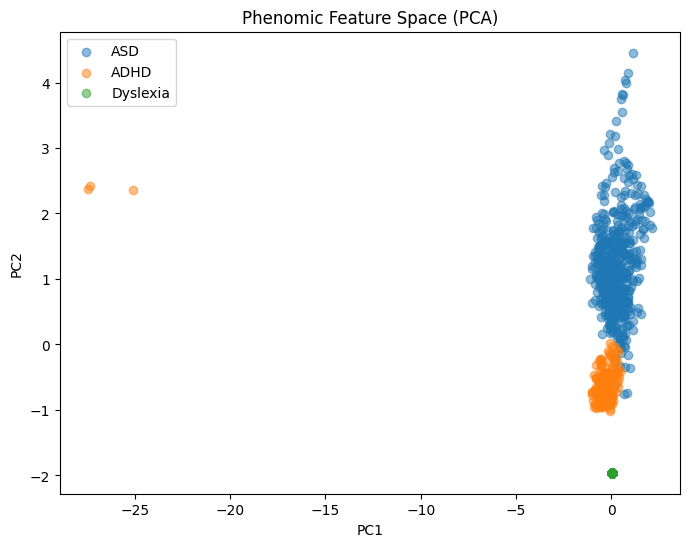

In [42]:
X = np.load("phenomic_X.npy")
Y = np.load("phenomic_Y.npy")  # Columns: ADHD, ASD, Dyslexia, Control

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

# ASD
plt.scatter(X_pca[Y[:,1]==1,0], X_pca[Y[:,1]==1,1], 
            alpha=0.5, label='ASD')

# ADHD
plt.scatter(X_pca[Y[:,0]==1,0], X_pca[Y[:,0]==1,1], 
            alpha=0.5, label='ADHD')

# Dyslexia
plt.scatter(X_pca[Y[:,2]==1,0], X_pca[Y[:,2]==1,1], 
            alpha=0.5, label='Dyslexia')

# # Control
# plt.scatter(X_pca[Y[:,3]==1,0], X_pca[Y[:,3]==1,1], 
#             alpha=0.5, label='Control', color='gray')

plt.legend()
plt.title("Phenomic Feature Space (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Observation:
- Most samples cluster in the top-right corner.
- ASD and ADHD clusters are close to each other, but not overlapping.
- Dyslexia samples form a small cluster slightly apart from the ASD/ADHD cluster.

Interpretation:
- PCA captures the directions of maximum variance.
- The fact that ASD and ADHD are close means they share similar variance patterns in the phenomic features, while Dyslexia is more distinct.
- Clusters being in the same corner is normal; PCA does not center them by disorder — it’s just a projection along the first two principal components.
- Small spread of Dyslexia indicates fewer samples and slightly different feature patterns.

The PCA plot shows that ADHD and ASD samples are close in the principal component space, suggesting shared phenomic feature patterns, while Dyslexia samples are slightly separated. The clusters are concentrated, indicating that the variance in the features is largely explained along a small set of directions, but separation is still visible.”

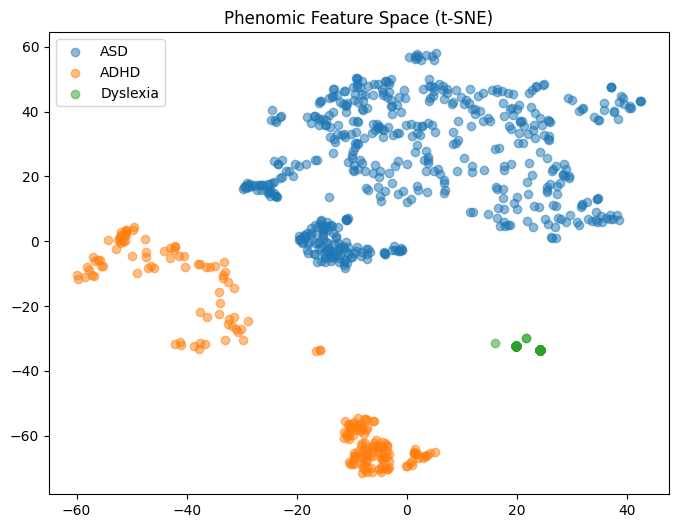

In [43]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[Y[:,1]==1,0], X_tsne[Y[:,1]==1,1], alpha=0.5, label='ASD')
plt.scatter(X_tsne[Y[:,0]==1,0], X_tsne[Y[:,0]==1,1], alpha=0.5, label='ADHD')
plt.scatter(X_tsne[Y[:,2]==1,0], X_tsne[Y[:,2]==1,1], alpha=0.5, label='Dyslexia')
plt.legend()
plt.title("Phenomic Feature Space (t-SNE)")
plt.show()

Observation:
- Clusters are more spread out and visually separated.
- ADHD splits into two sub-clusters, located on either side of the ASD cluster.
- ASD is widely clustered.
- Dyslexia is a small cluster, slightly distant from the other two.

Interpretation:
- t-SNE preserves local similarity, so nearby points in high-dimensional space stay close in 2D.
- ADHD splitting into two sub-clusters suggests heterogeneity within ADHD, maybe due to different subtypes or feature patterns.
- ASD being tightly clustered indicates homogeneous phenomic features.
- Dyslexia being small and separated reflects distinct feature patterns and fewer samples.

The t-SNE plot, which preserves local distances, shows clearer separation between the three disorders. ADHD samples form two sub-clusters on either side of ASD, suggesting internal heterogeneity. ASD samples form a tight cluster, indicating similar phenomic features across subjects, while Dyslexia samples are distant and fewer, consistent with PCA results. Overall, the plots suggest that the phenomic features can distinguish between the three disorders, but ADHD may have multiple subtypes reflected in the feature space.